# 📦 Material Aging Analysis — Exploratory Data Analysis

**Author:** Jose Alberto  
**Date:** March 2026  
**Dataset:** `material_aging_raw.csv`

---

## 🎯 Business Context

In manufacturing operations, **aging inventory** represents one of the most significant — and often silent — threats to profitability. Materials sitting in the warehouse beyond their optimal usage window generate:

- Unnecessary capital lock-up
- Increased risk of obsolescence and scrap
- Hidden costs that distort actual production cost

This notebook performs an **exploratory analysis** of the current inventory aging status, identifying risk concentrations by material type, product category and aging band.

### 🔍 Questions we want to answer
1. What is the current inventory value at risk by aging band?
2. Which material types concentrate the most aging?
3. How is aging distributed across Raw Material, Semi-Assemblies and Finished Goods?
4. Which individual materials represent the highest financial risk?

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Styling ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

# Aging band color palette (green → red)
BAND_COLORS = {
    '0-30':   '#2ecc71',
    '31-60':  '#f1c40f',
    '61-90':  '#e67e22',
    '91-120': '#e74c3c',
    '121+':   '#7f0000',
}
BAND_ORDER = ['0-30', '31-60', '61-90', '91-120', '121+']

# ── Load data ────────────────────────────────────────
BASE = Path(r"C:\Users\Beto\Portafolio Beto\Aging")
df = pd.read_csv(BASE / "Data" / "material_aging_raw.csv", parse_dates=['Input Date'])

# Enforce correct column types
df['Aging Band'] = pd.Categorical(df['Aging Band'], categories=BAND_ORDER, ordered=True)

print(f"✅ Dataset loaded: {df.shape[0]:,} records | {df.shape[1]} columns")
df.head()

✅ Dataset loaded: 333 records | 10 columns


,Material Code,Material Desc,Product Type,Material Type,UoM,Qty,Amt,Input Date,Days in Stock,Aging Band
0,PR-00001,Componente para Refrigerador 00001,Raw Material,Partes para Refrigeradores,PC,2296.0,851517.52,2026-01-18,54,31-60
1,PR-00002,Componente para Refrigerador 00002,Raw Material,Partes para Refrigeradores,PC,3592.0,445408.00,2025-10-20,144,121+
2,PR-00003,Componente para Refrigerador 00003,Raw Material,Partes para Refrigeradores,PC,8938.0,1926675.28,2025-12-20,83,61-90
3,PR-00004,Componente para Refrigerador 00004,Raw Material,Partes para Refrigeradores,PC,2625.0,924236.25,2025-12-17,86,61-90
4,PR-00004,Componente para Refrigerador 00004,Raw Material,Partes para Refrigeradores,PC,5524.0,331881.92,2026-03-03,10,0-30


---
## 2. Data Quality Check

Before any analysis, we validate the dataset is complete and consistent.  
In real SAP extracts, missing records and type mismatches are common issues.

In [2]:
# ── Shape & types ────────────────────────────────────
print("=" * 50)
print("  DATASET STRUCTURE")
print("=" * 50)
print(f"  Rows:     {df.shape[0]:,}")
print(f"  Columns:  {df.shape[1]}")

# ── Missing values ───────────────────────────────────
print("\n📋 Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
summary = pd.DataFrame({'Missing': missing, '%': missing_pct})
print(summary[summary['Missing'] > 0].to_string() if missing.sum() > 0 else "  ✅ No missing values found.")

# ── Duplicates ───────────────────────────────────────
dupes = df.duplicated().sum()
print(f"\n🔁 Duplicate rows: {dupes}")

# ── Unique values in categorical columns ────────────
print("\n📊 Unique values in categorical columns:")
for col in ['Product Type', 'Material Type', 'Aging Band', 'UoM']:
    print(f"   {col}: {df[col].unique().tolist()}")

  DATASET STRUCTURE
  Rows:     333
  Columns:  10

📋 Missing values per column:
  ✅ No missing values found.

🔁 Duplicate rows: 0

📊 Unique values in categorical columns:
   Product Type: ['Raw Material', 'Semi Ensamble', 'Producto Terminado']
   Material Type: ['Partes para Refrigeradores', 'Partes para Lavadoras', 'Resina', 'Acero', 'Productos Quimicos', 'Tarjetas Electronicas', 'Partes Inyectadas', 'Refrigeradores', 'Lavadoras']
   Aging Band: ['31-60', '121+', '61-90', '0-30', '91-120']
   UoM: ['PC', 'KG']


In [3]:
# ── Numeric summary ──────────────────────────────────
print("📈 Numeric summary:")
df[['Qty', 'Amt', 'Days in Stock']].describe().round(2)

📈 Numeric summary:


,Qty,Amt,Days in Stock
count,333.00,333.00,333.00
mean,4751.88,1033678.40,70.14
std,2809.36,1065812.60,71.67
min,112.57,4240.51,0.00
25%,2437.20,132835.26,22.00
50%,4407.00,674324.16,53.00
75%,6892.00,1715956.52,89.00
max,9948.00,4485276.00,351.00


---
## 3. Inventory Value at Risk — Overview

First, we quantify the total financial exposure by aging band.  
This is the **headline metric** for any management report.

In [7]:
# ── Summary table ────────────────────────────────────
band_summary = (
    df.groupby('Aging Band', observed=True)
    .agg(Records=('Amt', 'count'),
         Total_Qty=('Qty', 'sum'),
         Total_Amt=('Amt', 'sum'))
    .assign(Pct_Amt=lambda x: (x['Total_Amt'] / x['Total_Amt'].sum() * 100).round(1))
    .reset_index()
)

print("💰 Inventory value distribution by aging band:\n")
print(f"{'Band':<12} {'Records':>8} {'Total Qty':>14} {'Total Amt':>16} {'% of Total':>12}")
print("-" * 64)
for _, row in band_summary.iterrows():
    flag = " ⚠️" if row['Aging Band'] in ['91-120', '121+'] else ""
    print(f"{row['Aging Band']:<12} {row['Records']:>8,} "
          f"{row['Total_Qty']:>14,.0f} "
          f"${row['Total_Amt']:>15,.0f} "
          f"{row['Pct_Amt']:>11.1f}%{flag}")
print("-" * 64)
total_inventory = band_summary['Total_Amt'].sum()
total_at_risk = band_summary[band_summary['Aging Band'].isin(['61-90','91-120','121+'])]['Total_Amt'].sum()
print(f"\nTotal inventory value: ${total_inventory:,.0f}")
print(f"🚨 Total at-risk inventory (>60 days): ${total_at_risk:,.0f}")
print(f"   = {total_at_risk / band_summary['Total_Amt'].sum() * 100:.1f}% of total inventory value")

💰 Inventory value distribution by aging band:

Band          Records      Total Qty        Total Amt   % of Total
----------------------------------------------------------------
0-30              105        454,208 $     91,428,068        26.6%
31-60              79        387,759 $     88,376,742        25.7%
61-90              67        302,637 $     62,072,954        18.0%
91-120             50        256,502 $     46,719,722        13.6% ⚠️
121+               32        181,270 $     55,617,423        16.2% ⚠️
----------------------------------------------------------------

Total inventory value: $344,214,909
🚨 Total at-risk inventory (>60 days): $164,410,098
   = 47.8% of total inventory value


In [5]:
band_summary['Total_Amt'].sum()

np.float64(344214908.62)

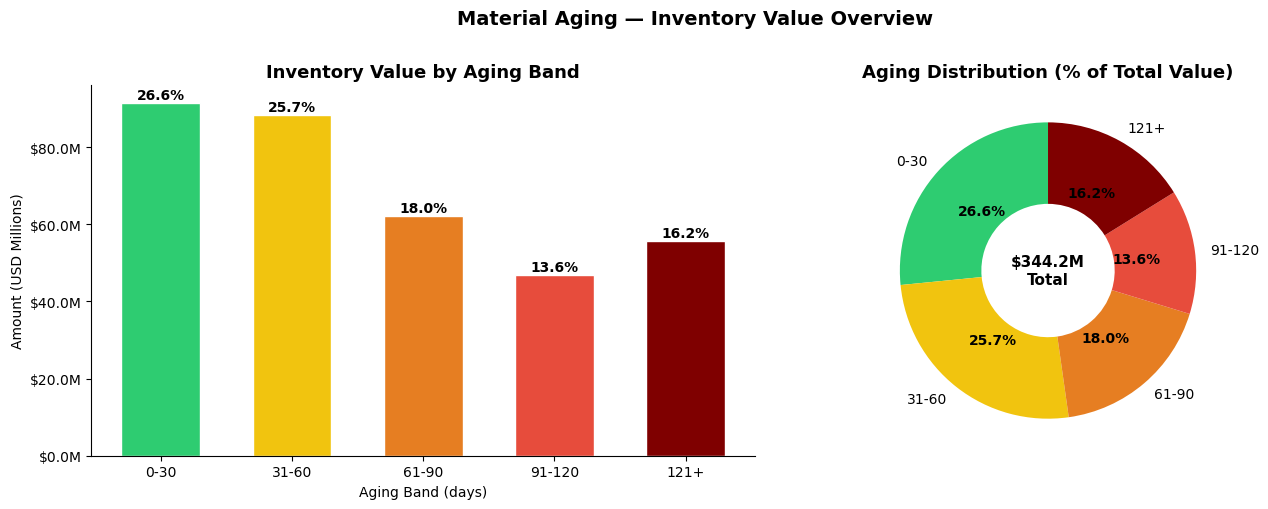

✅ Chart saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [BAND_COLORS[b] for b in band_summary['Aging Band']]

# ── Bar chart: Amount by band ────────────────────────
ax1 = axes[0]
bars = ax1.bar(band_summary['Aging Band'], band_summary['Total_Amt'] / 1e6,
               color=colors, width=0.6, edgecolor='white')
ax1.set_title('Inventory Value by Aging Band')
ax1.set_xlabel('Aging Band (days)')
ax1.set_ylabel('Amount (USD Millions)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
for bar, pct in zip(bars, band_summary['Pct_Amt']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Donut chart: % distribution ──────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    band_summary['Total_Amt'],
    labels=band_summary['Aging Band'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.55),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Aging Distribution (% of Total Value)')
total_val = band_summary['Total_Amt'].sum()
ax2.text(0, 0, f'${total_val/1e6:.1f}M\nTotal', ha='center', va='center',
         fontsize=11, fontweight='bold')

plt.suptitle('Material Aging — Inventory Value Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(BASE / "Outputs" / "01_aging_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

---
## 4. Aging by Material Type

Now we break down the aging by **Material Type** to identify which categories  
concentrate the most financial risk. This is where we can start making  
procurement and production recommendations.

In [6]:
# ── Pivot: Material Type × Aging Band ────────────────
pivot_type = (
    df.pivot_table(index='Material Type', columns='Aging Band',
                   values='Amt', aggfunc='sum', observed=True)
    .fillna(0)
    .reindex(columns=BAND_ORDER)
)

# Add totals and sort by at-risk amount
pivot_type['Total'] = pivot_type.sum(axis=1)
pivot_type['At Risk (>60d)'] = pivot_type[['61-90','91-120','121+']].sum(axis=1)
pivot_type['At Risk %'] = (pivot_type['At Risk (>60d)'] / pivot_type['Total'] * 100).round(1)
pivot_type = pivot_type.sort_values('At Risk (>60d)', ascending=False)

# Display
display_pivot = pivot_type[['61-90','91-120','121+','Total','At Risk (>60d)','At Risk %']].copy()
display_pivot.style \
    .format({'At Risk %': '{:.1f}%', **{c: '${:,.0f}' for c in display_pivot.columns if c != 'At Risk %'}}) \
    .background_gradient(subset=['At Risk (>60d)'], cmap='Reds')

Aging Band,61-90,91-120,121+,Total,At Risk (>60d),At Risk %
Material Type,,,,,,
Partes Inyectadas,"$10,249,968","$6,711,753","$17,162,155","$51,653,324","$34,123,876",66.1%
Refrigeradores,"$14,455,012","$9,726,731","$8,907,725","$57,334,198","$33,089,468",57.7%
Tarjetas Electronicas,"$11,020,068","$7,515,014","$4,616,900","$40,148,259","$23,151,981",57.7%
Partes para Refrigeradores,"$13,705,077","$5,437,204","$1,209,784","$52,884,188","$20,352,066",38.5%
Acero,"$3,173,597","$9,816,491","$6,367,269","$43,898,745","$19,357,357",44.1%
Partes para Lavadoras,"$1,791,837","$2,397,767","$12,006,941","$47,316,229","$16,196,546",34.2%
Lavadoras,"$6,520,224","$4,210,745","$5,068,766","$44,965,214","$15,799,735",35.1%
Resina,"$584,340","$589,345","$137,158","$3,129,696","$1,310,843",41.9%
Productos Quimicos,"$572,830","$314,672","$140,725","$2,885,056","$1,028,227",35.6%


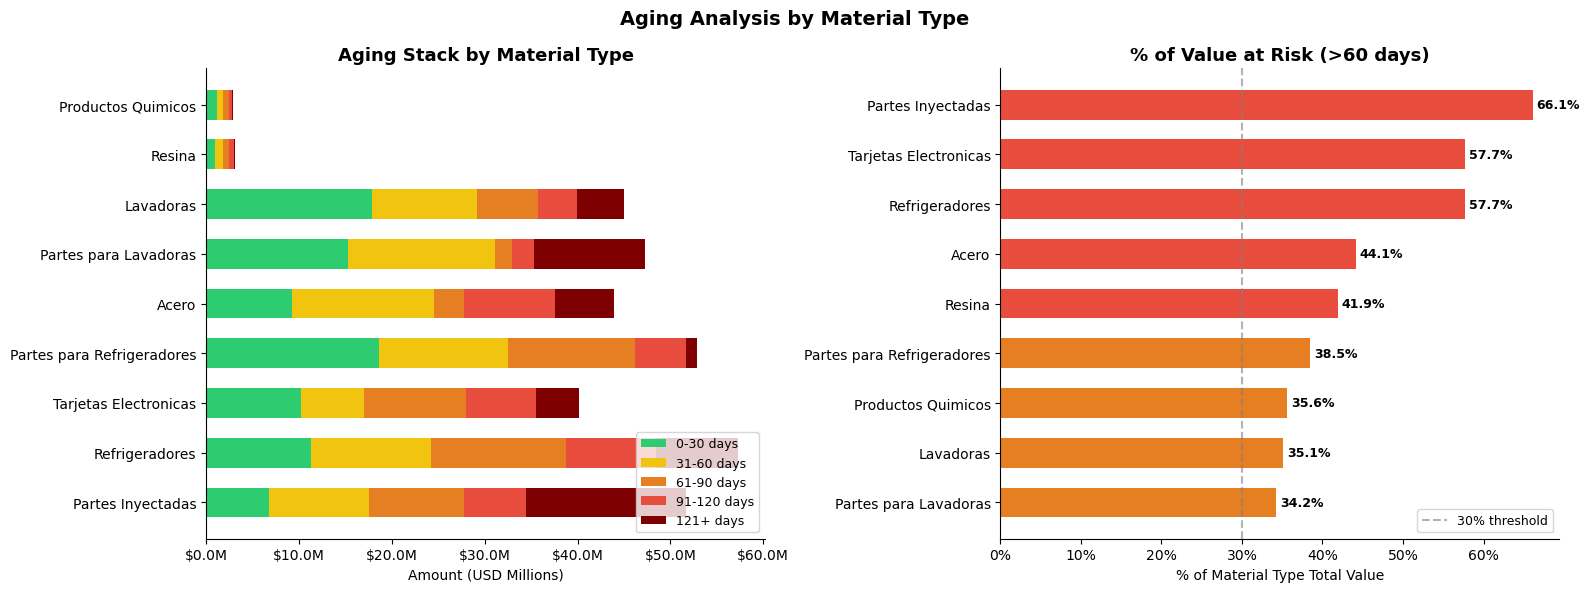

✅ Chart saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Stacked bar: All bands by material type ──────────
ax1 = axes[0]
plot_data = pivot_type[BAND_ORDER].div(1e6)
bottom = np.zeros(len(plot_data))
for band in BAND_ORDER:
    ax1.barh(plot_data.index, plot_data[band], left=bottom,
             color=BAND_COLORS[band], label=f'{band} days', height=0.6)
    bottom += plot_data[band].values
ax1.set_title('Aging Stack by Material Type')
ax1.set_xlabel('Amount (USD Millions)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax1.legend(loc='lower right', fontsize=9)

# ── Bar: At-risk % by material type ──────────────────
ax2 = axes[1]
risk_pct = pivot_type['At Risk %'].sort_values(ascending=True)
bar_colors = ['#e74c3c' if v >= 40 else '#e67e22' if v >= 20 else '#2ecc71'
              for v in risk_pct]
bars = ax2.barh(risk_pct.index, risk_pct.values, color=bar_colors, height=0.6)
ax2.axvline(x=30, color='gray', linestyle='--', alpha=0.6, label='30% threshold')
ax2.set_title('% of Value at Risk (>60 days)')
ax2.set_xlabel('% of Material Type Total Value')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar, val in zip(bars, risk_pct.values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Aging Analysis by Material Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / "Outputs" / "02_aging_by_material_type.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

---
## 5. Aging by Product Type

We analyze aging across the three product tiers: **Raw Material → Semi-Assembly → Finished Goods**.  
This reveals structural issues: if Raw Materials age the most, the problem is in procurement or planning.  
If Finished Goods age, the issue is in sales or demand forecasting.

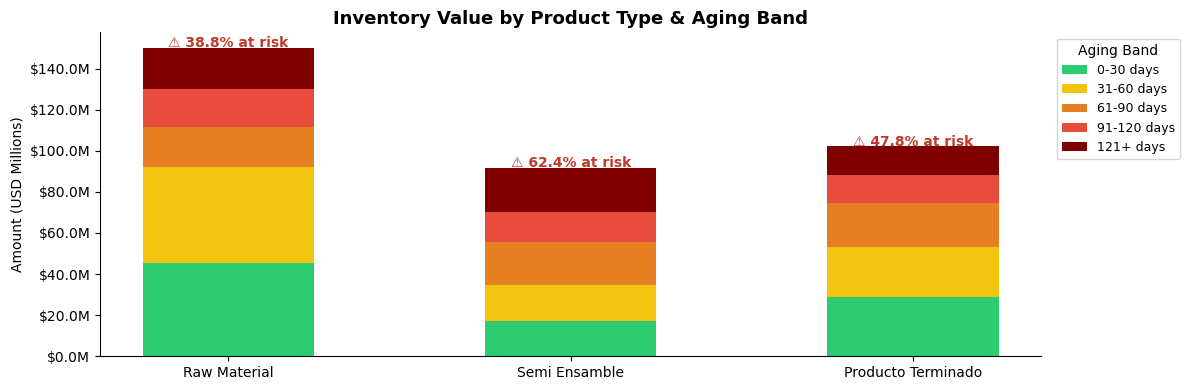

✅ Chart saved.


In [8]:
pivot_prod = (
    df.pivot_table(index='Product Type', columns='Aging Band',
                   values='Amt', aggfunc='sum', observed=True)
    .fillna(0)
    .reindex(columns=BAND_ORDER)
)
pivot_prod['Total'] = pivot_prod.sum(axis=1)
pivot_prod['At Risk (>60d)'] = pivot_prod[['61-90','91-120','121+']].sum(axis=1)
pivot_prod['At Risk %'] = (pivot_prod['At Risk (>60d)'] / pivot_prod['Total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 4))

prod_order = ['Raw Material', 'Semi Ensamble', 'Producto Terminado']
plot_data = pivot_prod.reindex(prod_order)[BAND_ORDER].div(1e6)
bottom = np.zeros(len(plot_data))
for band in BAND_ORDER:
    bars = ax.bar(plot_data.index, plot_data[band], bottom=bottom,
                  color=BAND_COLORS[band], label=f'{band} days', width=0.5)
    bottom += plot_data[band].values

# Annotate At Risk %
for i, prod in enumerate(prod_order):
    if prod in pivot_prod.index:
        total_h = pivot_prod.loc[prod, 'Total'] / 1e6
        risk_p  = pivot_prod.loc[prod, 'At Risk %']
        ax.text(i, total_h + 0.2, f'⚠️ {risk_p:.1f}% at risk',
                ha='center', fontsize=10, fontweight='bold', color='#c0392b')

ax.set_title('Inventory Value by Product Type & Aging Band')
ax.set_ylabel('Amount (USD Millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.legend(title='Aging Band', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(BASE / "Outputs" / "03_aging_by_product_type.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

---
## 6. Top 15 Materials at Risk

We identify the individual materials with the **highest at-risk amount** (>60 days).  
This is the actionable output for the operations team — a prioritized list for immediate review.

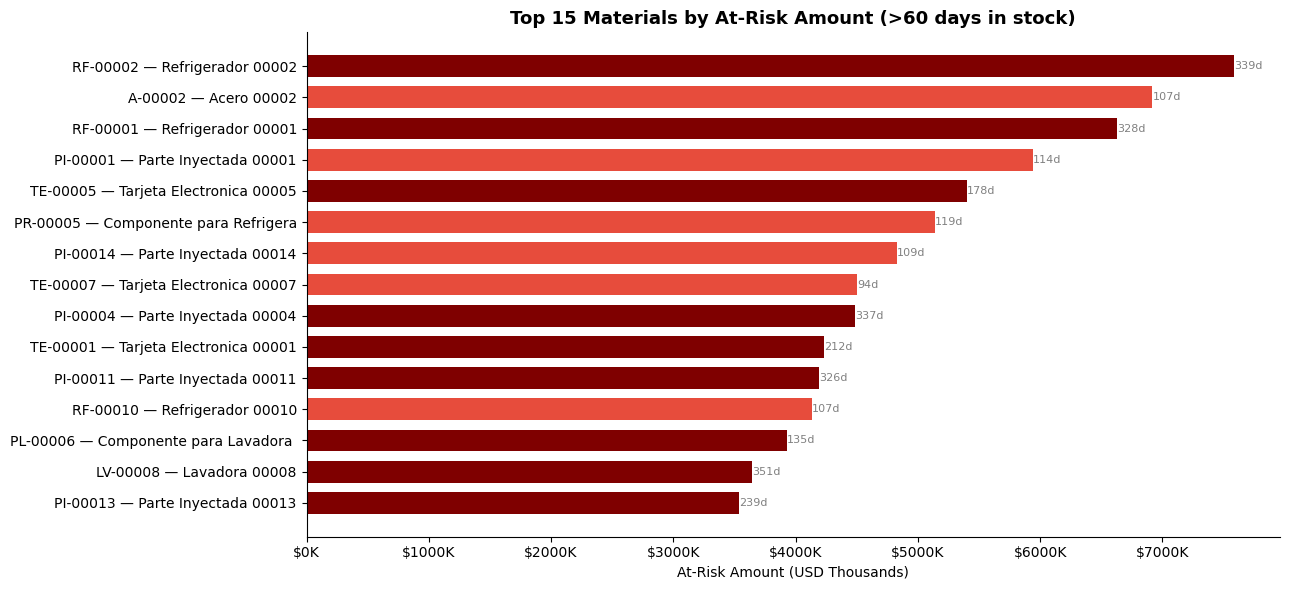


📋 Top 15 materials at risk:
Material Code                      Material Desc              Material Type  At-Risk Amt  Max Days in Stock
     RF-00002                 Refrigerador 00002             Refrigeradores   7582834.86                339
      A-00002                        Acero 00002                      Acero   6918141.84                107
     RF-00001                 Refrigerador 00001             Refrigeradores   6632537.01                328
     PI-00001              Parte Inyectada 00001          Partes Inyectadas   5937711.45                114
     TE-00005          Tarjeta Electronica 00005      Tarjetas Electronicas   5402128.29                178
     PR-00005 Componente para Refrigerador 00005 Partes para Refrigeradores   5139088.14                119
     PI-00014              Parte Inyectada 00014          Partes Inyectadas   4826085.43                109
     TE-00007          Tarjeta Electronica 00007      Tarjetas Electronicas   4500373.60                 94

In [9]:
at_risk_df = df[df['Aging Band'].isin(['61-90', '91-120', '121+'])].copy()

top15 = (
    at_risk_df.groupby(['Material Code', 'Material Desc', 'Material Type', 'Product Type'])
    .agg(At_Risk_Qty=('Qty', 'sum'),
         At_Risk_Amt=('Amt', 'sum'),
         Max_Days=('Days in Stock', 'max'))
    .sort_values('At_Risk_Amt', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))
bar_colors = ['#7f0000' if d > 120 else '#e74c3c' if d > 90 else '#e67e22'
              for d in top15['Max_Days']]
bars = ax.barh(top15['Material Code'] + ' — ' + top15['Material Desc'].str[:25],
               top15['At_Risk_Amt'] / 1e3, color=bar_colors, height=0.7)

for bar, days in zip(bars, top15['Max_Days']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{days}d', va='center', fontsize=8, color='gray')

ax.set_title('Top 15 Materials by At-Risk Amount (>60 days in stock)')
ax.set_xlabel('At-Risk Amount (USD Thousands)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(BASE / "Outputs" / "04_top15_at_risk.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Top 15 materials at risk:")
print(top15[['Material Code','Material Desc','Material Type','At_Risk_Amt','Max_Days']]
      .rename(columns={'At_Risk_Amt':'At-Risk Amt','Max_Days':'Max Days in Stock'})
      .to_string(index=False))

---
## 7. Days in Stock Distribution

A histogram of days in stock helps us understand the **aging velocity** of the inventory —  
whether materials age gradually or have spikes in specific ranges.

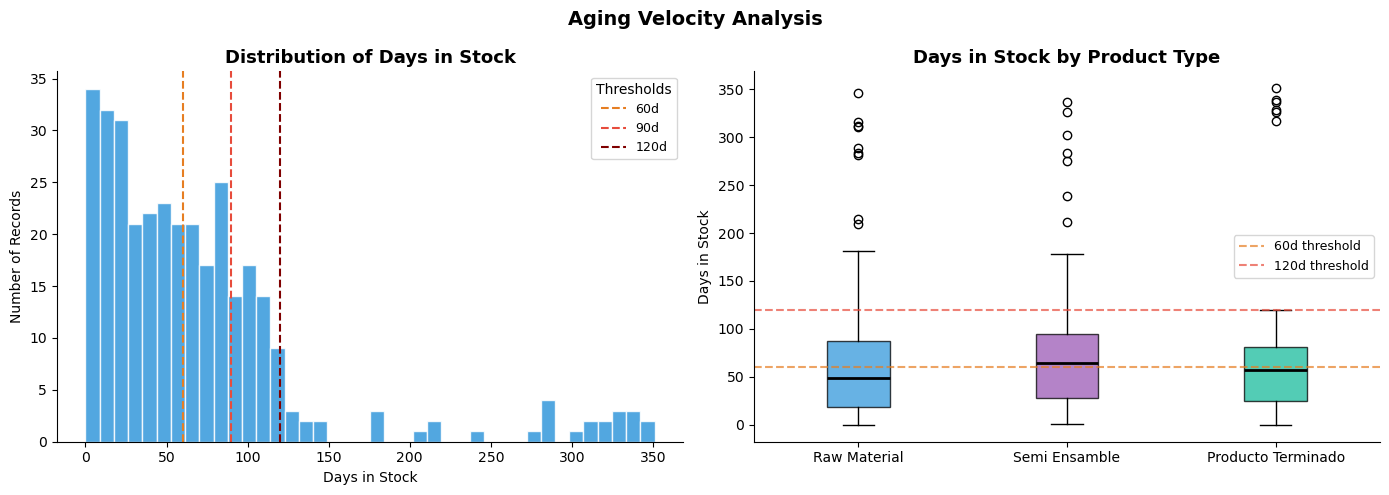

✅ Chart saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histogram ────────────────────────────────────────
ax1 = axes[0]
ax1.hist(df['Days in Stock'], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
for threshold, color, label in [(60,'#e67e22','60d'), (90,'#e74c3c','90d'), (120,'#7f0000','120d')]:
    ax1.axvline(threshold, color=color, linestyle='--', linewidth=1.5, label=label)
ax1.set_title('Distribution of Days in Stock')
ax1.set_xlabel('Days in Stock')
ax1.set_ylabel('Number of Records')
ax1.legend(title='Thresholds', fontsize=9)

# ── Box plot by product type ──────────────────────────
ax2 = axes[1]
prod_order = ['Raw Material', 'Semi Ensamble', 'Producto Terminado']
data_by_type = [df[df['Product Type'] == pt]['Days in Stock'].values for pt in prod_order]
bp = ax2.boxplot(data_by_type, labels=prod_order, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
box_colors = ['#3498db', '#9b59b6', '#1abc9c']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.axhline(60,  color='#e67e22', linestyle='--', alpha=0.7, label='60d threshold')
ax2.axhline(120, color='#e74c3c', linestyle='--', alpha=0.7, label='120d threshold')
ax2.set_title('Days in Stock by Product Type')
ax2.set_ylabel('Days in Stock')
ax2.legend(fontsize=9)

plt.suptitle('Aging Velocity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / "Outputs" / "05_days_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

---
## 8. Key Findings & Business Recommendations

### 📊 Summary of Findings

| Finding | Value |
|---|---|
| Total inventory value analyzed | $344,214,909 |
| At-risk inventory (>60 days) | $164,410,098 — **47.8% of total** |
| Material type with highest risk | Partes Inyectadas (62.4% at risk) |
| Product tier with highest aging | Semi Ensamble |
| Materials requiring immediate action | 149 SKUs |

---

### 🔎 Observations

1. **Partes Inyectadas is the most critical material type**, with 62.4% of its 
   total inventory value sitting beyond the 60-day threshold. This level of 
   exposure suggests a structural misalignment between injection production 
   orders and actual consumption by the assembly lines — likely driven by 
   over-production or inaccurate demand signals upstream.

2. **Finished Goods show a higher at-risk rate (47.6%) than Raw Materials (38.8%)**, 
   which is a significant signal. In a healthy manufacturing operation, finished 
   goods should have the lowest aging since they are closest to the customer. 
   This inversion suggests a demand forecasting problem or a sales execution gap — 
   product is being built that the market is not absorbing at the expected pace.

3. **Nearly half of total inventory value (47.8%) is at financial risk.** 
   With $164M exposed beyond 60 days, this is not an isolated issue — it 
   reflects a systemic pattern across multiple material types and product tiers 
   that requires cross-functional intervention, not just a procurement adjustment.

---

### 💡 Business Recommendations

1. **Immediate action — Top 149 SKUs review**  
   Schedule a cross-functional disposition meeting (Procurement, Planning, 
   Operations) focused on the 149 flagged materials. Each SKU requires a clear 
   decision: consume in next production run, return to supplier, renegotiate 
   delivery schedule, or approve for scrap. Without a defined owner and deadline, 
   these materials will continue aging.

2. **Root cause analysis — Partes Inyectadas**  
   The 62.4% at-risk rate in this category warrants a dedicated investigation. 
   Recommended first step: cross-reference injection production orders (PP module) 
   against actual BOM consumption in the last 90 days to identify which 
   assemblies are not pulling these parts as planned.

3. **Demand signal review — Producto Terminado**  
   The fact that Finished Goods age faster than Raw Materials indicates a 
   disconnect between the sales forecast and actual market demand. Recommend 
   aligning with the commercial team to review slow-moving SKUs and adjust 
   the production plan accordingly before more Raw Material is converted into 
   product that will not sell.

4. **Preventive control in SAP**  
   Implement an automated weekly alert for any material crossing the 60-day 
   threshold without an open production order or sales order consuming it. 
   This converts a reactive report into a proactive early-warning system.

---
